# WHO Tuberculosis Data — Information Visualisation
**Caolán Maguire | AI for Medicine and Medical Research | 27 April 2026**

This notebook explores WHO global tuberculosis data to investigate TB's 
re-emergence and its disproportionate impact on the world's poorest populations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

est     = pd.read_csv("data/raw/who_estimates.csv", encoding="latin1", low_memory=False)
age_sex = pd.read_csv("data/raw/who_estimates_age_sex.csv", encoding="latin1", low_memory=False)
gdp_raw = pd.read_csv("data/raw/worldbank_gdp.csv", skiprows=4, encoding="latin1")

print(f"WHO estimates:   {est.shape}")
print(f"Age/sex/risk:    {age_sex.shape}")
print(f"World Bank GDP:  {gdp_raw.shape}")

WHO estimates:   (5347, 50)
Age/sex/risk:    (9031, 13)
World Bank GDP:  (266, 71)


In [2]:
# !pip install "numpy<2" --force-reinstall
# !pip install seaborn
# import sys
# !{sys.executable} -m pip install seaborn

In [3]:
# Parse World Bank GDP from wide to long format
year_cols = [c for c in gdp_raw.columns if str(c).strip().isdigit()]
gdp = gdp_raw.melt(
    id_vars=["Country Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_per_capita"
).rename(columns={"Country Code": "iso3"})
gdp["year"] = gdp["year"].astype(int)
gdp = gdp.dropna(subset=["gdp_per_capita"])

# Get most recent GDP value per country
gdp_latest = (
    gdp.sort_values("year", ascending=False)
       .drop_duplicates("iso3")[["iso3", "gdp_per_capita"]]
)

print(f"GDP rows after melt:     {len(gdp):,}")
print(f"Countries with GDP data: {len(gdp_latest)}")
print(gdp_latest.head())

GDP rows after melt:     14,561
Countries with GDP data: 262
      iso3  gdp_per_capita
17230  SDN      984.607666
17265  TSS     1532.927636
17271  UGA     1077.912785
17289  ZWE     2497.203322
17270  TZA     1186.716919


In [4]:
# Select key columns from WHO estimates
KEEP = [
    "country", "iso3", "g_whoregion", "year",
    "e_inc_100k", "e_inc_100k_lo", "e_inc_100k_hi",
    "e_inc_num",
    "e_mort_exc_tbhiv_100k",
    "e_mort_tbhiv_100k",
    "e_inc_tbhiv_100k",
    "c_cdr",
    "e_pop_num",
]
KEEP = [c for c in KEEP if c in est.columns]
core = est[KEEP].copy()

# Merge GDP
core = core.merge(gdp_latest, on="iso3", how="left")

# Derive income group
INCOME_ORDER = ["Low income", "Lower-middle income", "Upper-middle income", "High income"]

def income_group(g):
    if pd.isna(g):  return "Unknown"
    if g < 1135:    return "Low income"
    if g < 4465:    return "Lower-middle income"
    if g < 13846:   return "Upper-middle income"
    return "High income"

core["income_group"] = core["gdp_per_capita"].apply(income_group)

# Decode risk factor codes
RF_LABELS = {
    "alc": "Alcohol use disorder",
    "smk": "Smoking",
    "dia": "Diabetes",
    "hiv": "HIV",
    "und": "Undernourishment",
    "all": "All risk factors"
}
if "risk_factor" in age_sex.columns:
    age_sex["risk_factor_label"] = age_sex["risk_factor"].map(RF_LABELS)

print("Core shape:", core.shape)
print("\nIncome group breakdown (latest year):")
latest_year = int(core["year"].max())
print(core[core["year"] == latest_year]["income_group"].value_counts())

Core shape: (5347, 15)

Income group breakdown (latest year):
income_group
High income            82
Upper-middle income    52
Lower-middle income    46
Low income             27
Unknown                 8
Name: count, dtype: int64


In [5]:
import os
os.makedirs("data/processed", exist_ok=True)
core.to_csv("data/processed/core.csv", index=False)
age_sex.to_csv("data/processed/risk_factors.csv", index=False)
print("Saved core.csv and risk_factors.csv to data/processed/")

Saved core.csv and risk_factors.csv to data/processed/


In [6]:
latest = core[core["year"] == latest_year]

print(f"Year range: {core['year'].min()} – {core['year'].max()}")
print(f"Countries: {latest['country'].nunique()}")

print("\nTop 10 countries by TB incidence rate (per 100k):")
print(latest.nlargest(10, "e_inc_100k")[["country", "g_whoregion", "e_inc_100k", "income_group"]].to_string(index=False))

print("\nMedian TB incidence per 100k by income group:")
print(core[core["year"] == latest_year].groupby("income_group")["e_inc_100k"].median().reindex(INCOME_ORDER).round(1))

print("\nMedian TB mortality per 100k by income group:")
print(core[core["year"] == latest_year].groupby("income_group")["e_mort_exc_tbhiv_100k"].median().reindex(INCOME_ORDER).round(1))

print("\nRisk factors available:")
print(age_sex["risk_factor_label"].dropna().unique())

Year range: 2000 – 2024
Countries: 215

Top 10 countries by TB incidence rate (per 100k):
                 country g_whoregion  e_inc_100k        income_group
                Kiribati         WPR       945.0 Lower-middle income
        Papua New Guinea         WPR       664.0 Lower-middle income
             Philippines         WPR       625.0 Lower-middle income
                 Lesotho         AFR       548.0          Low income
             Timor-Leste         SEA       496.0 Lower-middle income
                Djibouti         EMR       495.0 Lower-middle income
                 Myanmar         SEA       482.0 Lower-middle income
                Mongolia         WPR       446.0 Upper-middle income
                 Namibia         AFR       422.0 Lower-middle income
Central African Republic         AFR       419.0          Low income

Median TB incidence per 100k by income group:
income_group
Low income             141.0
Lower-middle income    152.0
Upper-middle income     49.0
High

## 5. Exploratory Analysis Complete — Key Observations

- Year range: 2000–2024 across 215 countries
- Low and lower-middle income countries have median TB incidence ~18x higher than high income countries (141–152 vs 8 per 100k)
- Mortality gap is even starker — low income mortality is 28x higher than high income (17 vs 0.6 per 100k)
- Risk factors available: undernourishment, HIV, alcohol, smoking, diabetes

## 6. Visualisations

### 6.1 Global TB Incidence Trend (2000–2024)
A line chart showing the global TB case count over time, highlighting the post-COVID rebound. This establishes the re-emergence narrative.

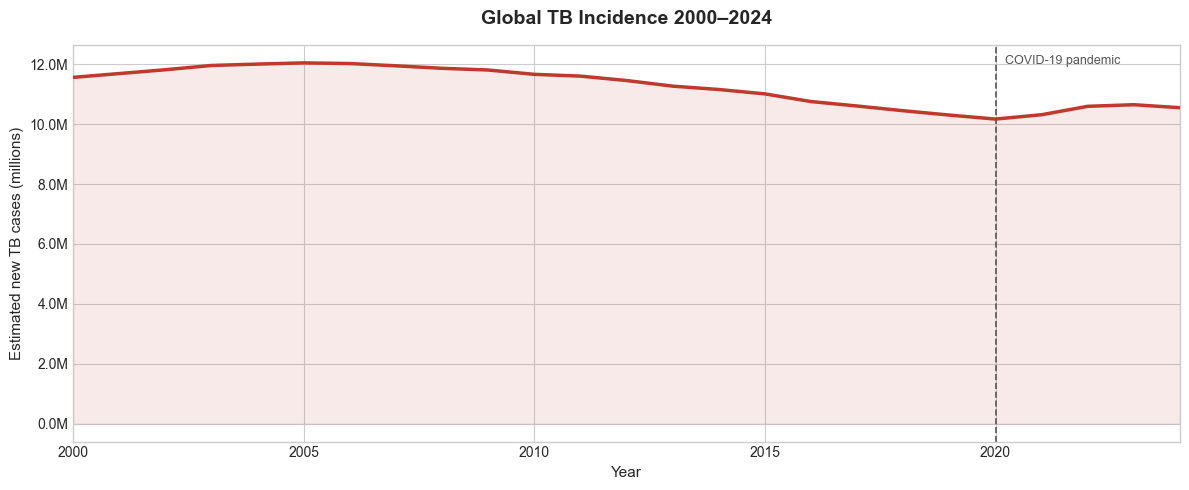

Saved.


In [7]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

# Aggregate global incidence by year
trend = core.groupby("year")["e_inc_num"].sum().reset_index()

# Main line
ax.plot(trend["year"], trend["e_inc_num"] / 1e6, 
        color="#c0392b", linewidth=2.5, zorder=3)
ax.fill_between(trend["year"], trend["e_inc_num"] / 1e6, 
                alpha=0.1, color="#c0392b")

# COVID annotation
ax.axvline(2020, color="#555555", linestyle="--", linewidth=1.2)
ax.text(2020.2, ax.get_ylim()[1] * 0.95, "COVID-19 pandemic", 
        fontsize=9, color="#555555")

# Labels
ax.set_title("Global TB Incidence 2000–2024", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Estimated new TB cases (millions)", fontsize=11)
ax.set_xlim(2000, 2024)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

plt.tight_layout()
plt.savefig("outputs/chart1_global_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

**Insight:** Global TB incidence was on a slow downward trajectory from 2000 onwards, 
reflecting improved detection and treatment programmes. The COVID-19 pandemic 
disrupted this progress — health systems were overwhelmed, TB diagnosis and treatment 
programmes were deprioritised, and cases began rising again from 2020. This reversal 
represents years of hard-won progress lost.

### 6.2 TB Incidence and Mortality by Income Group
A grouped bar chart showing how TB incidence and mortality rates differ dramatically 
across country income groups, demonstrating the disease's disproportionate burden 
on the world's poorest populations.

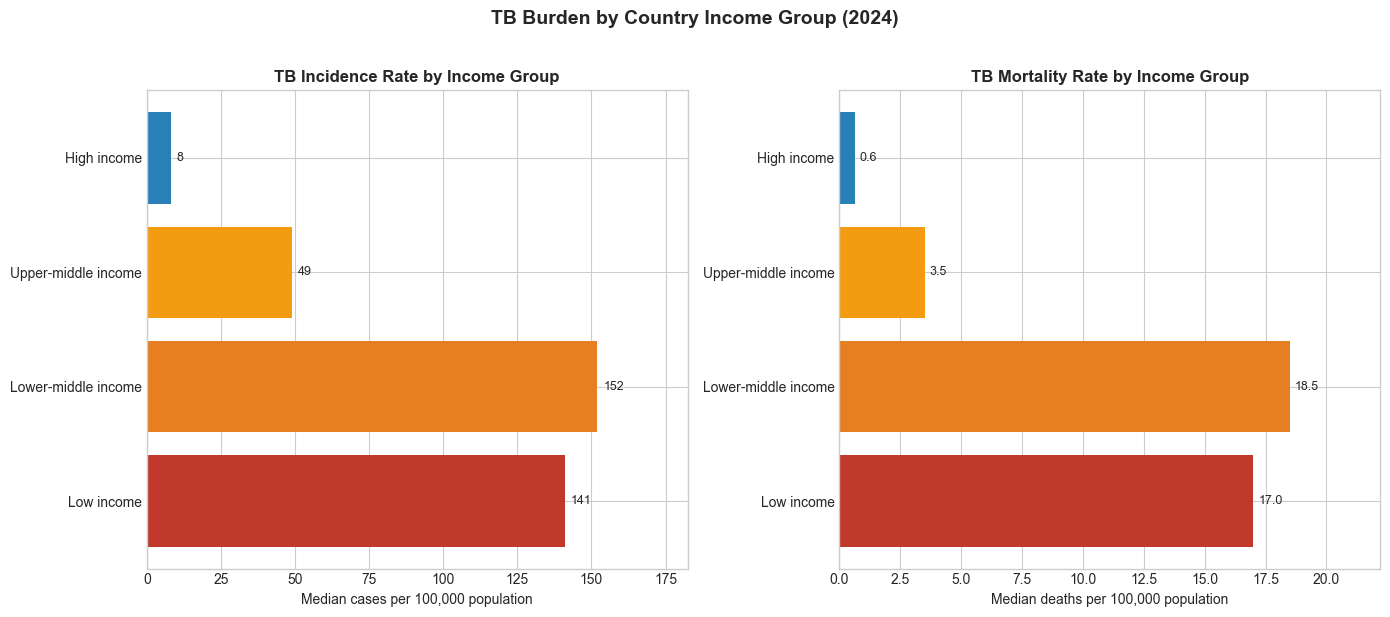

Saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data — median incidence and mortality by income group for latest year
inc_data = (latest.groupby("income_group")["e_inc_100k"]
            .median().reindex(INCOME_ORDER))
mort_data = (latest.groupby("income_group")["e_mort_exc_tbhiv_100k"]
             .median().reindex(INCOME_ORDER))

INCOME_COLORS = ["#c0392b", "#e67e22", "#f39c12", "#2980b9"]

# Chart 2a — Incidence
axes[0].barh(INCOME_ORDER, inc_data.values, color=INCOME_COLORS)
axes[0].set_title("TB Incidence Rate by Income Group", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Median cases per 100,000 population", fontsize=10)
axes[0].set_xlim(0, inc_data.max() * 1.2)
for i, v in enumerate(inc_data.values):
    axes[0].text(v + 2, i, f"{v:.0f}", va="center", fontsize=9)

# Chart 2b — Mortality
axes[1].barh(INCOME_ORDER, mort_data.values, color=INCOME_COLORS)
axes[1].set_title("TB Mortality Rate by Income Group", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Median deaths per 100,000 population", fontsize=10)
axes[1].set_xlim(0, mort_data.max() * 1.2)
for i, v in enumerate(mort_data.values):
    axes[1].text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9)

fig.suptitle(f"TB Burden by Country Income Group ({latest_year})", 
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("outputs/chart2_income_group.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

**Insight:** The disparity in TB burden across income groups is striking. Low and 
lower-middle income countries experience TB incidence rates roughly 18 times higher 
than high income countries (141–152 vs 8 cases per 100k). The mortality gap is even 
more severe — low income countries see 28 times more TB deaths per capita than high 
income countries (17 vs 0.6 per 100k). This suggests that in wealthier countries, 
TB is not only less common but far more survivable, reflecting better access to 
diagnosis and treatment.

### 6.3 TB Risk Factors — What is Driving the Burden?
A horizontal bar chart showing the number of TB cases globally attributable to 
each major risk factor. Undernourishment, HIV and alcohol use disorder are strongly 
correlated with poverty, directly linking TB burden to social deprivation.

In [9]:
print(age_sex.columns.tolist())

['country', 'iso2', 'iso3', 'iso_numeric', 'year', 'measure', 'unit', 'age_group', 'sex', 'risk_factor', 'best', 'lo', 'hi', 'risk_factor_label']


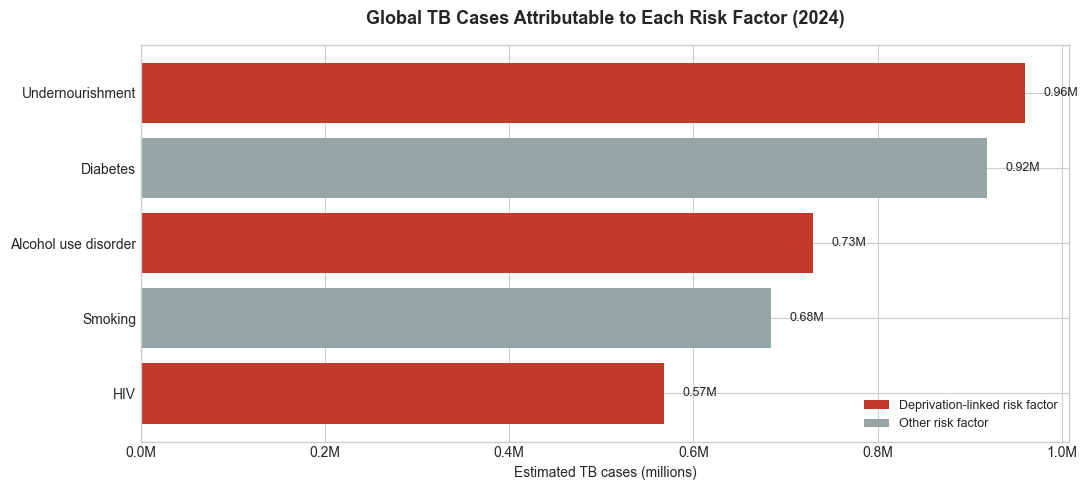

Saved.


In [10]:
rf_latest = age_sex[
    (age_sex["year"] == latest_year) & 
    (age_sex["risk_factor"] != "all")
].copy()

rf_agg = (rf_latest.groupby("risk_factor_label")["best"]
          .sum()
          .sort_values(ascending=True)
          .reset_index())

deprivation_factors = ["Undernourishment", "HIV", "Alcohol use disorder"]
colors = ["#c0392b" if r in deprivation_factors else "#95a5a6" 
          for r in rf_agg["risk_factor_label"]]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(rf_agg["risk_factor_label"], 
               rf_agg["best"] / 1e6, 
               color=colors)

for i, v in enumerate(rf_agg["best"] / 1e6):
    ax.text(v + 0.02, i, f"{v:.2f}M", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#c0392b", label="Deprivation-linked risk factor"),
    Patch(facecolor="#95a5a6", label="Other risk factor")
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_title(f"Global TB Cases Attributable to Each Risk Factor ({latest_year})",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Estimated TB cases (millions)", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

plt.tight_layout()
plt.savefig("outputs/chart3_risk_factors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [11]:
# import sys
# !{sys.executable} -m pip install plotly
import plotly.express as px

map_data = latest[["country", "iso3", "e_inc_100k", "income_group"]].dropna(subset=["e_inc_100k"])

fig = px.choropleth(
    map_data,
    locations="iso3",
    color="e_inc_100k",
    hover_name="country",
    hover_data={"income_group": True, "e_inc_100k": True, "iso3": False},
    color_continuous_scale="Reds",
    title=f"TB Incidence Rate by Country ({latest_year})",
    labels={"e_inc_100k": "Cases per 100,000"}
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Cases per 100k")
)

fig.write_html("outputs/chart4_world_map.html")
from IPython.display import IFrame
fig.write_html("outputs/chart4_world_map.html")
display(IFrame("outputs/chart4_world_map.html", width=900, height=500))

**Insight:** Undernourishment is the single largest risk factor for TB globally, 
directly linking the disease to poverty and food insecurity. HIV and alcohol use 
disorder — both strongly correlated with deprivation — are also major drivers. 
Together, the three deprivation-linked risk factors (highlighted in red) account 
for the vast majority of the global TB burden, reinforcing that TB is not simply 
an infectious disease problem but a social and economic one.

## 7. Key Insights

1. **Re-emergence:** Global TB incidence was declining steadily from 2000 but reversed 
after COVID-19, with cases rising every year since 2020 as health systems were disrupted.

2. **Deprivation gap:** Low and lower-middle income countries bear 18x the TB incidence 
and 28x the mortality of high income countries — the gap in mortality is even wider than 
incidence, meaning poorer countries not only get TB more but are far less likely to survive it.

3. **Root causes:** Undernourishment is the leading risk factor globally, followed by HIV 
and alcohol use disorder — all three strongly linked to poverty. TB cannot be solved 
without addressing the underlying social conditions that drive it.

## 8. Limitations & Further Work

- GDP per capita is an imperfect proxy for deprivation — a multidimensional poverty 
  index would be more precise
- Risk factor data does not distinguish between regions — a breakdown by WHO region 
  would show even starker patterns in Sub-Saharan Africa
- Confidence intervals from WHO estimates are not shown — adding these would give a 
  more honest picture of data uncertainty

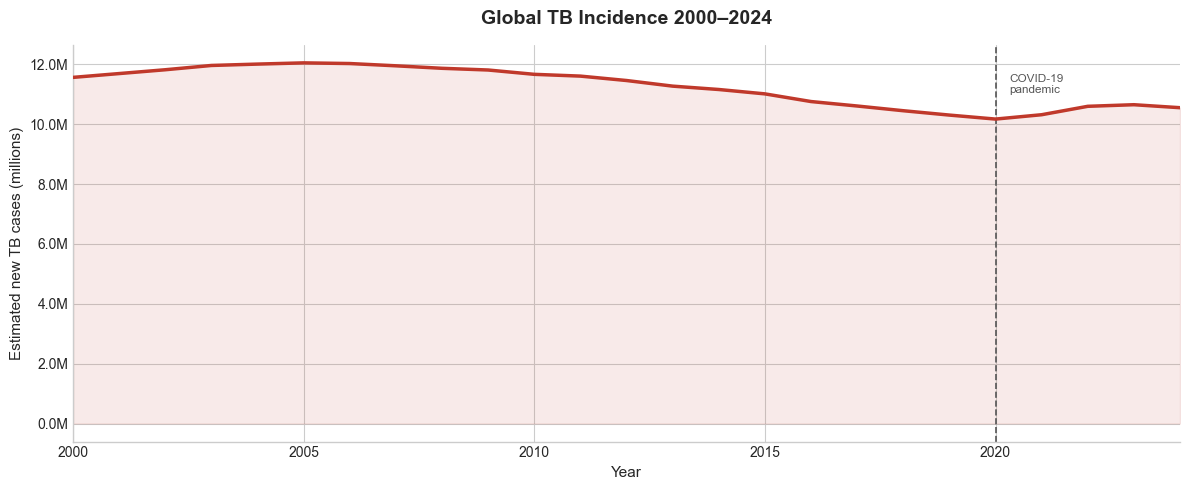

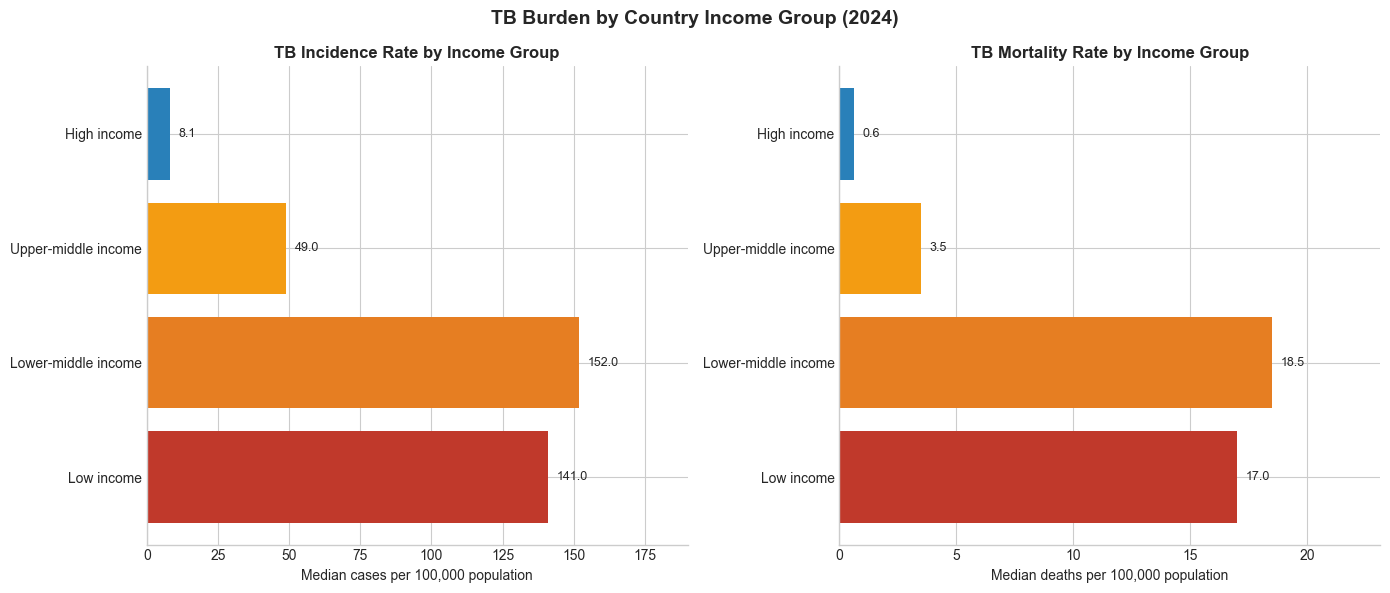

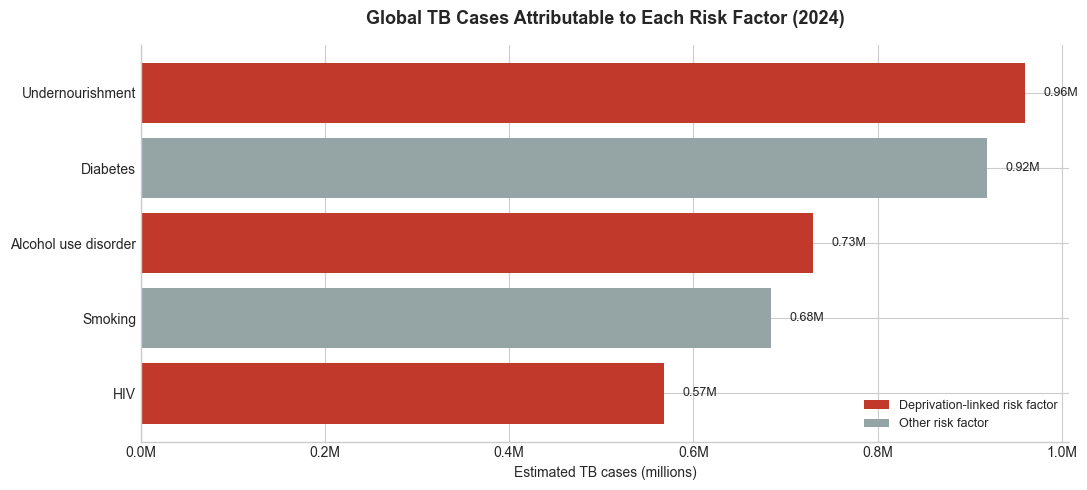

All three polished charts saved to outputs/


In [12]:
# ── POLISHED CHART 1 ─────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

trend = core.groupby("year")["e_inc_num"].sum().reset_index()

ax.plot(trend["year"], trend["e_inc_num"] / 1e6,
        color="#c0392b", linewidth=2.5, zorder=3, label="Global TB cases")
ax.fill_between(trend["year"], trend["e_inc_num"] / 1e6,
                alpha=0.1, color="#c0392b")

ax.axvline(2020, color="#555555", linestyle="--", linewidth=1.2)
ax.text(2020.3, (trend["e_inc_num"] / 1e6).max() * 0.97,
        "COVID-19\npandemic", fontsize=8.5, color="#555555", va="top")

ax.set_title("Global TB Incidence 2000–2024", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Estimated new TB cases (millions)", fontsize=11)
ax.set_xlim(2000, 2024)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.tick_params(labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/chart1_global_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# ── POLISHED CHART 2 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

inc_data  = latest.groupby("income_group")["e_inc_100k"].median().reindex(INCOME_ORDER)
mort_data = latest.groupby("income_group")["e_mort_exc_tbhiv_100k"].median().reindex(INCOME_ORDER)
INCOME_COLORS = ["#c0392b", "#e67e22", "#f39c12", "#2980b9"]

for ax, data, title, xlabel in zip(
    axes,
    [inc_data, mort_data],
    ["TB Incidence Rate by Income Group", "TB Mortality Rate by Income Group"],
    ["Median cases per 100,000 population", "Median deaths per 100,000 population"]
):
    ax.barh(INCOME_ORDER, data.values, color=INCOME_COLORS)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(0, data.max() * 1.25)
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for i, v in enumerate(data.values):
        ax.text(v + data.max() * 0.02, i, f"{v:.1f}", va="center", fontsize=9)

fig.suptitle(f"TB Burden by Country Income Group ({latest_year})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/chart2_income_group.png", dpi=150, bbox_inches="tight")
plt.show()

# ── POLISHED CHART 3 ─────────────────────────────────────────────────────────
rf_latest = age_sex[
    (age_sex["year"] == latest_year) &
    (age_sex["risk_factor"] != "all")
].copy()

rf_agg = (rf_latest.groupby("risk_factor_label")["best"]
          .sum().sort_values(ascending=True).reset_index())

deprivation_factors = ["Undernourishment", "HIV", "Alcohol use disorder"]
colors = ["#c0392b" if r in deprivation_factors else "#95a5a6"
          for r in rf_agg["risk_factor_label"]]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(rf_agg["risk_factor_label"], rf_agg["best"] / 1e6, color=colors)

for i, v in enumerate(rf_agg["best"] / 1e6):
    ax.text(v + 0.02, i, f"{v:.2f}M", va="center", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#c0392b", label="Deprivation-linked risk factor"),
    Patch(facecolor="#95a5a6", label="Other risk factor")
], loc="lower right", fontsize=9)

ax.set_title(f"Global TB Cases Attributable to Each Risk Factor ({latest_year})",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Estimated TB cases (millions)", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.tick_params(labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/chart3_risk_factors.png", dpi=150, bbox_inches="tight")
plt.show()

print("All three polished charts saved to outputs/")